In [10]:
import numpy as np
import scipy as sp
import soundfile as sf
import torch
import torch.nn as nn

data, samplerate = sf.read('data/train_audio/grekis/XC474863.ogg')
print(data.shape)
print(samplerate)
print(data[:10])
print(len(data)/samplerate)


(737280,)
32000
[-2.91330321e-06 -2.48165611e-06 -5.25708583e-06 -2.71547360e-05
 -3.05141361e-06 -1.73204660e-06  2.95067821e-05 -7.61043520e-06
  1.21042749e-05  1.46012580e-05]
23.04


In [14]:
fourier = np.fft.rfft(data)
print(fourier.shape)
print(fourier.real[:10])

(368641,)
[0.09176032 0.00025267 0.092545   0.01380226 0.08190364 0.02880291
 0.05918197 0.0551796  0.03713273 0.05951806]


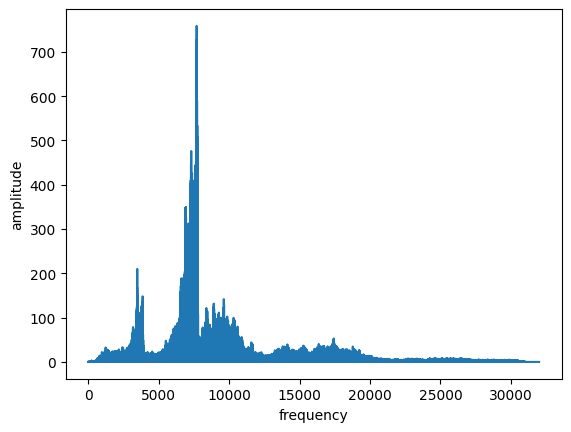

In [16]:
import matplotlib.pyplot as plt

w = np.linspace(0, samplerate, len(fourier))
fourier_to_plot = np.abs(fourier.real)

plt.plot(w, fourier_to_plot)
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.show()

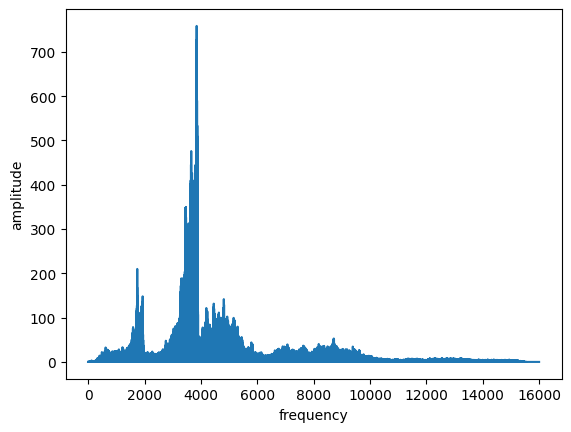

(368641,)


In [18]:
# compute frequency associated
# with coefficients
freqs = np.fft.rfftfreq(len(data), d=1/samplerate)
plt.plot(freqs, fourier_to_plot)    
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.show()
print(freqs.shape)

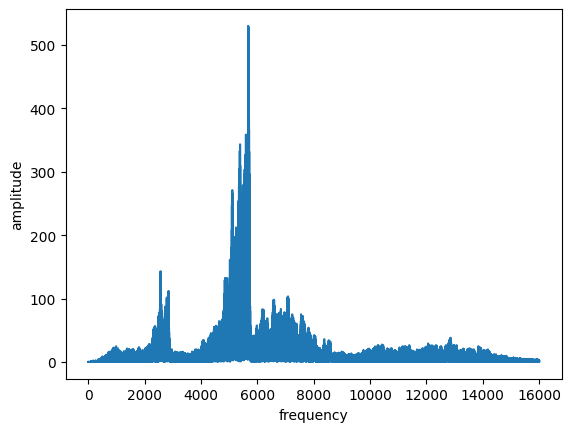

fourier bins: (250001,)
og size: 3.8147125244140625 MB
new size: 0.4768390655517578 MB


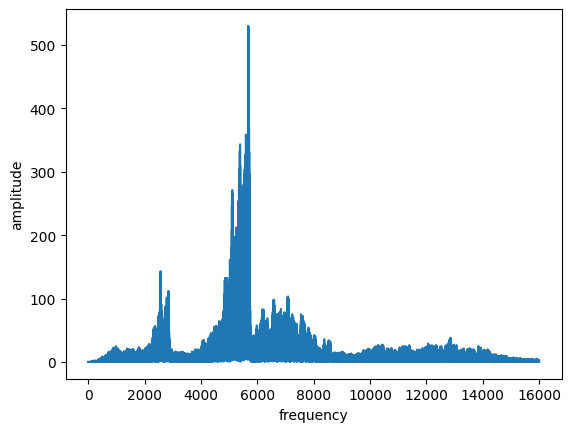

In [ ]:
resampled_data = sp.signal.resample(data, 500000)
fourier = np.fft.rfft(resampled_data)
freqs = np.fft.rfftfreq(len(resampled_data), d=1/samplerate)
plt.plot(freqs, np.abs(fourier))    
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.show()
print(f'fourier bins: {fourier.shape}')
print(f'og size: {fourier.nbytes/(1024**2)} MB')
fourier = np.abs(fourier)
fourier = fourier.astype(np.float16, copy=False)
print(f'new size: {fourier.nbytes/(1024**2)} MB')
plt.plot(freqs, fourier)    
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.show()



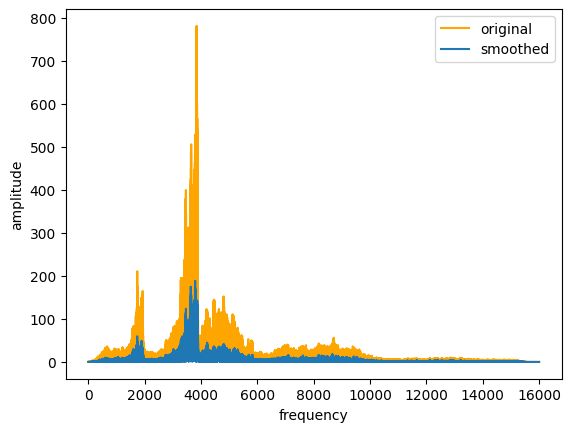

In [20]:
from scipy.ndimage import gaussian_filter1d

smoothed_fourier = gaussian_filter1d(fourier, sigma=2)
plt.plot(freqs, np.abs(fourier), label='original', color='orange')
plt.plot(freqs, np.abs(smoothed_fourier), label='smoothed')
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.legend()
plt.show()

In [25]:
# The maximum frequency is half the sample rate
points_per_freq = len(data) / (samplerate / 2)

nyquist_freq = samplerate / 2
print(f"Nyquist frequency: {nyquist_freq} Hz")

fft_bins = len(data)/2
resolution = nyquist_freq / fft_bins
print(f"FFT resolution: {resolution} Hz per bin")

bins = 0
for i in range(0, int(nyquist_freq), 10):
    idx = int(points_per_freq * i)
    print(f"Frequency: {i} Hz, Index: {idx}")
    bins += 1
print(f"Total bins: {bins}")

Nyquist frequency: 16000.0 Hz
FFT resolution: 0.043402777777777776 Hz per bin
Frequency: 0 Hz, Index: 0
Frequency: 10 Hz, Index: 460
Frequency: 20 Hz, Index: 921
Frequency: 30 Hz, Index: 1382
Frequency: 40 Hz, Index: 1843
Frequency: 50 Hz, Index: 2304
Frequency: 60 Hz, Index: 2764
Frequency: 70 Hz, Index: 3225
Frequency: 80 Hz, Index: 3686
Frequency: 90 Hz, Index: 4147
Frequency: 100 Hz, Index: 4608
Frequency: 110 Hz, Index: 5068
Frequency: 120 Hz, Index: 5529
Frequency: 130 Hz, Index: 5990
Frequency: 140 Hz, Index: 6451
Frequency: 150 Hz, Index: 6912
Frequency: 160 Hz, Index: 7372
Frequency: 170 Hz, Index: 7833
Frequency: 180 Hz, Index: 8294
Frequency: 190 Hz, Index: 8755
Frequency: 200 Hz, Index: 9216
Frequency: 210 Hz, Index: 9676
Frequency: 220 Hz, Index: 10137
Frequency: 230 Hz, Index: 10598
Frequency: 240 Hz, Index: 11059
Frequency: 250 Hz, Index: 11520
Frequency: 260 Hz, Index: 11980
Frequency: 270 Hz, Index: 12441
Frequency: 280 Hz, Index: 12902
Frequency: 290 Hz, Index: 13363


In [ ]:
X_train = fourier_to_plot
y_train = np.array([0])  # dummy label

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).long()
X_train.to(device)
y_train.to(device)
train_ds = TensorDataset(X_train, y_train)

batch_size = 256
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [ ]:
input_size = X_train.shape[1]
hidden_units = [input_size, input_size//2, input_size//4]

all_layers = nn.ModuleList()
#all_layers.append(nn.Flatten())
#all_layers = [nn.Flatten()]
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit
all_layers.append(nn.Linear(hidden_units[-1], len(class_le.classes_)))   
#all_layers.append(nn.Softmax(dim=3))
model = nn.Sequential(*all_layers)
model.to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(1)
num_epochs = 20
for epoch in range(num_epochs):
    accuracy_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch.to(device))
        loss = loss_fn(pred, y_batch.to(device))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct = (torch.argmax(pred, dim=1) == y_batch.to(device)).float()
        accuracy_hist_train += is_correct.sum().cpu()
    accuracy_hist_train /= len(train_dl.dataset)
    print(f'Epoch {epoch}  Accuracy {accuracy_hist_train:.4f}')

In [ ]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from matplotlib import pyplot as plt

with torch.no_grad():
    y_pred = torch.argmax(model(X_test), dim=1)
print(balanced_accuracy_score(y_test, y_pred))